# Zero-Population Nodes

Shows only zero-population tracts (WHITE + BLACK == 0, matching `gen_duals.py`'s `CONTRACTION_POP_COLS`) and their immediate neighbours for 2020, overlaid on the corresponding tract shapefiles.

- **Red polygons / crimson nodes**: zero-pop tracts
- **Blue polygons / steelblue nodes**: their neighbours

In [87]:
import json
import glob
import os


In [88]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

YEAR                  = 2020
CBSA_DIR              = '../study_areas'
CENSUS_GEOGRAPHY_TYPE = 'tracts'

_cbsa_df  = pd.read_csv('cbsa-name dictionary.csv')
cbsa_dict = dict(zip(_cbsa_df['CBSA Code'], _cbsa_df['CBSA Name']))

In [89]:
def find_orig_file(cbsa_code):
    """Return the _orig.json filepath for 2020 (pre-contraction graph), or None."""
    pattern = os.path.join(
        CBSA_DIR, str(YEAR),
        f'{CENSUS_GEOGRAPHY_TYPE}_in_cbsa_{cbsa_code}_{YEAR}_*_vintage_orig.json'
    )
    matches = sorted(glob.glob(pattern))
    return matches[0] if matches else None


def load_graph(filepath):
    with open(filepath) as f:
        d = json.load(f)
    nodes_list = d['nodes']
    G = nx.Graph()
    for node in nodes_list:
        G.add_node(node['id'], **node)
    for i, neighbours in enumerate(d['adjacency']):
        src_id = nodes_list[i]['id']
        for nb in neighbours:
            j = nb['id']
            if src_id < j:
                G.add_edge(src_id, j)
    return G


def is_zero_pop(attrs):
    white = int(attrs.get('WHITE') or 0)
    black = int(attrs.get('BLACK') or 0)
    return white + black == 0

In [90]:
def plot_zero_pop_nodes(cbsa_code):
    fp = find_orig_file(cbsa_code)
    if fp is None:
        print(f'No orig file found for CBSA {cbsa_code} in {YEAR}')
        return

    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))
    G = load_graph(fp)

    zero_nodes     = {n for n, d in G.nodes(data=True) if is_zero_pop(d)}
    neighbor_nodes = {nb for n in zero_nodes for nb in G.neighbors(n) if nb not in zero_nodes}
    target_nodes   = zero_nodes | neighbor_nodes

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(
        f'{cbsa_name} — {YEAR}\n'
        f'{len(zero_nodes)} zero-pop tracts · {len(neighbor_nodes)} neighbours',
        fontsize=13, fontweight='bold'
    )

    if not zero_nodes:
        ax.text(0.5, 0.5, 'No zero-pop nodes', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_axis_off()
        plt.show()
        return

    # --- Shapefile overlay (only target tracts) ---
    shp_path = fp.replace('_orig.json', '.shp')
    if os.path.exists(shp_path):
        gdf = gpd.read_file(shp_path).to_crs('esri:102003')

        zero_gisjoin     = {G.nodes[n].get('GISJOIN') for n in zero_nodes}
        neighbor_gisjoin = {G.nodes[n].get('GISJOIN') for n in neighbor_nodes}

        gdf[gdf['GISJOIN'].isin(neighbor_gisjoin)].plot(
            ax=ax, color='#b8d4e8', edgecolor='#555', linewidth=0.5, alpha=0.75
        )
        gdf[gdf['GISJOIN'].isin(zero_gisjoin)].plot(
            ax=ax, color='#f4a8a8', edgecolor='#990000', linewidth=0.7, alpha=0.9
        )

        xlim, ylim = ax.get_xlim(), ax.get_ylim()
    else:
        print(f'  Shapefile not found: {shp_path}')
        xlim, ylim = None, None

    # --- Graph overlay (subgraph of target nodes only) ---
    H   = G.subgraph(target_nodes)
    pos = {n: (G.nodes[n]['centroid_x'], G.nodes[n]['centroid_y']) for n in target_nodes}

    nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.35, width=0.7, edge_color='#444')
    nx.draw_networkx_nodes(
        H, pos, nodelist=list(neighbor_nodes), ax=ax,
        node_color='steelblue', node_size=20, alpha=0.85
    )
    nx.draw_networkx_nodes(
        H, pos, nodelist=list(zero_nodes), ax=ax,
        node_color='crimson', node_size=40, alpha=0.95
    )

    # Restore shapefile extent (networkx draw calls can widen it)
    if xlim:
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)

    legend_elements = [
        Patch(facecolor='#f4a8a8', edgecolor='#990000', label='Zero-pop tract'),
        Patch(facecolor='#b8d4e8', edgecolor='#555',    label='Neighbour tract'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='crimson',
               markersize=9, label='Zero-pop node'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=7, label='Neighbour node'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.85)
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()

    # --- Degree report ---
    print(f'\n{cbsa_name} — zero-pop node degrees')
    print(f'{"Node":>6}  {"GISJOIN":<16}  {"Degree":>6}')
    print('-' * 34)
    for n in sorted(zero_nodes, key=lambda n: G.degree(n), reverse=True):
        gisjoin = G.nodes[n].get('GISJOIN', '')
        print(f'{n:>6}  {gisjoin:<16}  {G.degree(n):>6}')

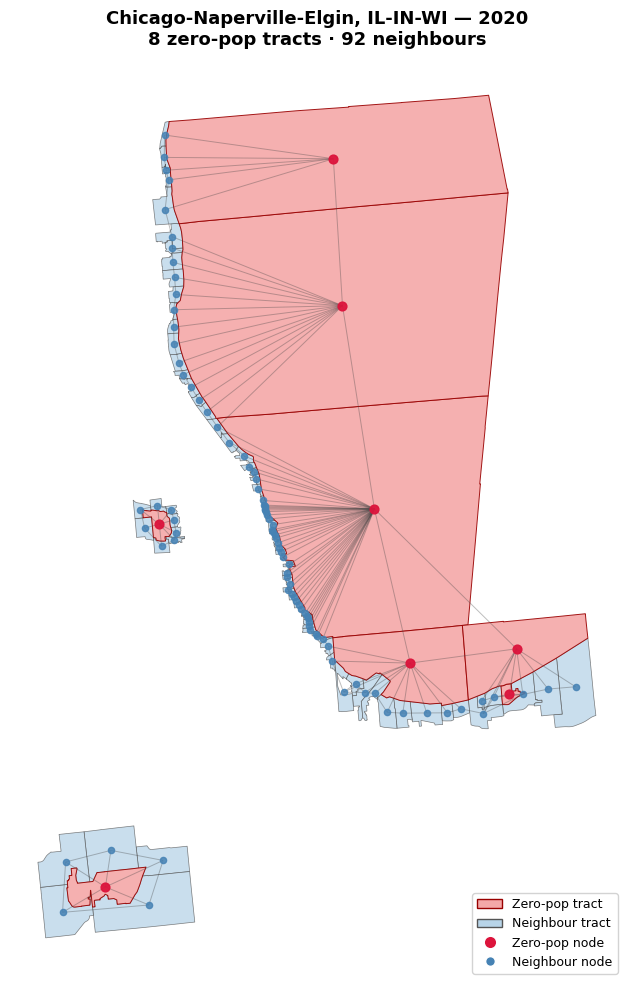


Chicago-Naperville-Elgin, IL-IN-WI — zero-pop node degrees
  Node  GISJOIN           Degree
----------------------------------
  1413  G17031990000          47
  2094  G17097990000          16
  2232  G18089990000          13
  2289  G18127990000           9
  1341  G17031980000           8
  2327  G55059990000           6
   616  G17197980000           5
  2167  G18127980002           3


In [91]:
plot_zero_pop_nodes(16980)

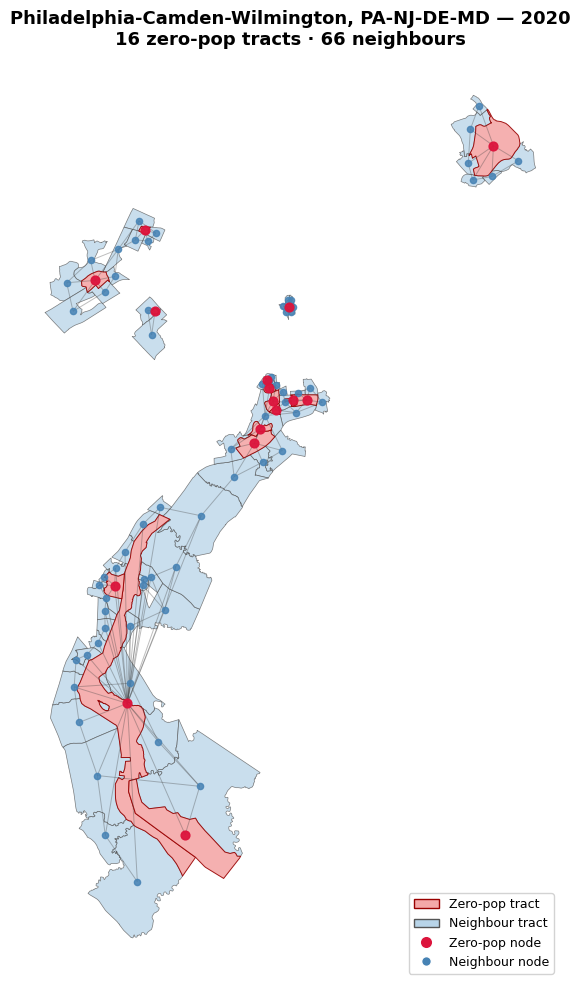


Philadelphia-Camden-Wilmington, PA-NJ-DE-MD — zero-pop node degrees
  Node  GISJOIN           Degree
----------------------------------
    93  G10003990100          27
   515  G42045980000           6
   611  G42101980904           6
   613  G42101980906           6
   551  G42101980701           6
  1063  G42091980200           6
  1353  G42017980000           6
   757  G42101980500           6
   102  G10003980100           5
   610  G42101980902           4
   614  G42101980905           4
  1054  G42091980000           4
  1542  G42101980600           3
   753  G42101980400           3
  1027  G42045980200           2
   378  G34033990000           2


In [92]:
plot_zero_pop_nodes(37980)

In [93]:
def save_zero_pop_shapefile(cbsa_code, out_dir='/Users/samstephenson/Desktop/ZERO POP'):
    fp = find_orig_file(cbsa_code)
    if fp is None:
        print(f'No orig file found for CBSA {cbsa_code} in {YEAR}')
        return

    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))
    city_name = cbsa_name.split('-')[0].split(',')[0].strip()
    G = load_graph(fp)

    zero_nodes = {n for n, d in G.nodes(data=True) if is_zero_pop(d)}

    if not zero_nodes:
        print(f'{cbsa_name}: no zero-pop nodes found')
        return

    shp_path = fp.replace('_orig.json', '.shp')
    if not os.path.exists(shp_path):
        print(f'Shapefile not found: {shp_path}')
        return

    gdf = gpd.read_file(shp_path).to_crs('esri:102003')

    zero_gisjoin = {G.nodes[n].get('GISJOIN') for n in zero_nodes}
    out = gdf[gdf['GISJOIN'].isin(zero_gisjoin)].copy()

    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f'{city_name}_zero_pop_{YEAR}.shp')
    out.to_file(out_path)
    print(f'Saved {len(out)} zero-pop tracts → {out_path}')


for cbsa_code in [16980, 37980, 35620, 19100, 31080]:
    save_zero_pop_shapefile(cbsa_code)

Saved 8 zero-pop tracts → /Users/samstephenson/Desktop/ZERO POP/Chicago_zero_pop_2020.shp
Saved 16 zero-pop tracts → /Users/samstephenson/Desktop/ZERO POP/Philadelphia_zero_pop_2020.shp
Saved 63 zero-pop tracts → /Users/samstephenson/Desktop/ZERO POP/New York_zero_pop_2020.shp
Saved 1 zero-pop tracts → /Users/samstephenson/Desktop/ZERO POP/Dallas_zero_pop_2020.shp
Saved 14 zero-pop tracts → /Users/samstephenson/Desktop/ZERO POP/Los Angeles_zero_pop_2020.shp


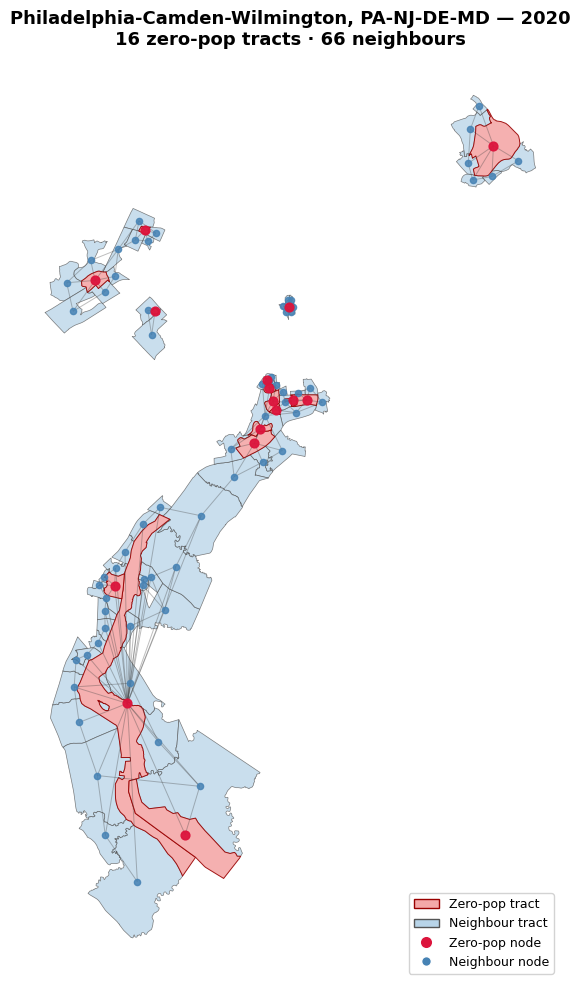


Philadelphia-Camden-Wilmington, PA-NJ-DE-MD — zero-pop node degrees
  Node  GISJOIN           Degree
----------------------------------
    93  G10003990100          27
   515  G42045980000           6
   611  G42101980904           6
   613  G42101980906           6
   551  G42101980701           6
  1063  G42091980200           6
  1353  G42017980000           6
   757  G42101980500           6
   102  G10003980100           5
   610  G42101980902           4
   614  G42101980905           4
  1054  G42091980000           4
  1542  G42101980600           3
   753  G42101980400           3
  1027  G42045980200           2
   378  G34033990000           2


In [94]:
plot_zero_pop_nodes(37980)

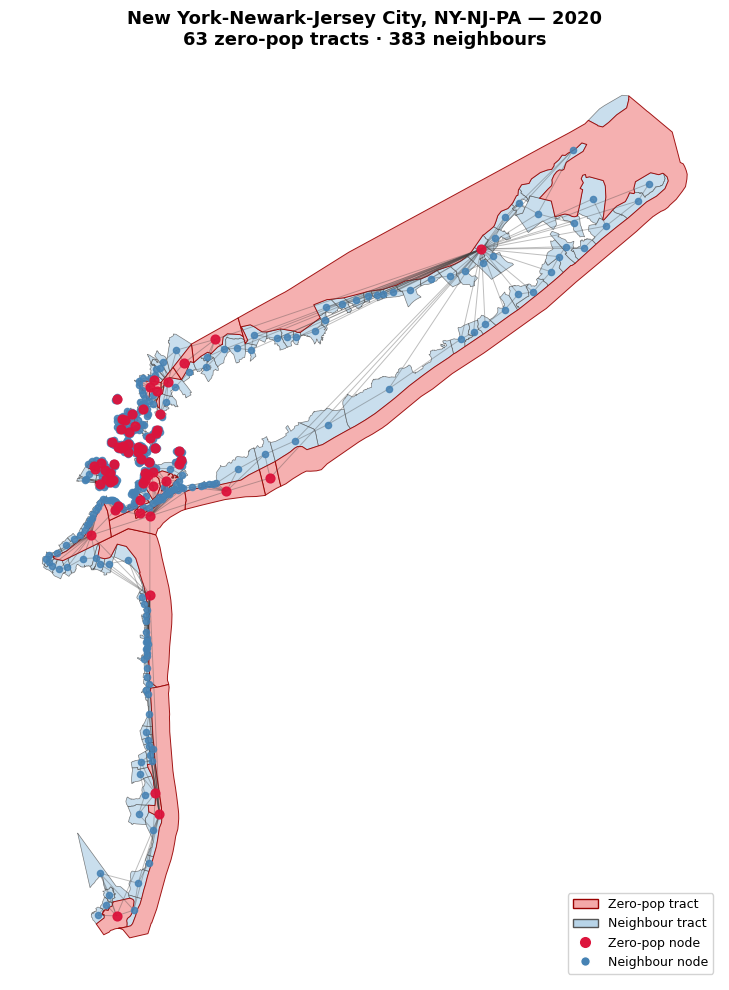


New York-Newark-Jersey City, NY-NJ-PA — zero-pop node degrees
  Node  GISJOIN           Degree
----------------------------------
  2626  G36103990100          47
   157  G34025990000          25
  3261  G36085990100          24
  1704  G36081990100          19
  2065  G36047990100          18
  1430  G34029990000          17
  2357  G36059990100          14
  4913  G36081107202          14
  4060  G36047066600          14
  2767  G36005050400          12
  4581  G36047017500          12
  1918  G36047118000          11
  4693  G36059990400          10
  3034  G36081022900          10
  4069  G36047070203          10
  4846  G36081033100          10
  1459  G34017980100           9
  3482  G36005011000           8
  2481  G36005001903           8
  3559  G36047102802           8
  2315  G36061008602           7
  1428  G34029980000           7
  3610  G36081062400           7
  3914  G36081065501           7
  3544  G36047103402           7
  2930  G36081009900           7
  3581  G36

In [95]:
plot_zero_pop_nodes(35620)

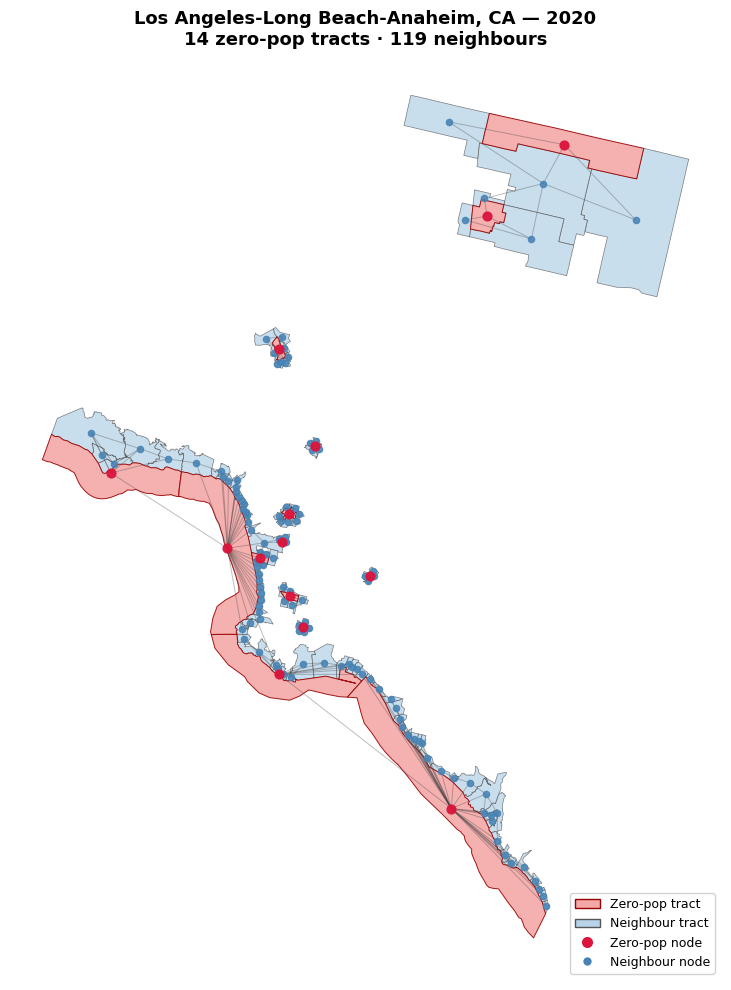


Los Angeles-Long Beach-Anaheim, CA — zero-pop node degrees
  Node  GISJOIN           Degree
----------------------------------
   673  G06037990200          31
  2529  G06059990100          29
   636  G06037990300          15
  2433  G06037980022           8
  2434  G06037980030           8
  2437  G06037980038           7
   635  G06037990100           6
   251  G06037980005           5
  2557  G06037980037           5
  2439  G06037980039           4
  3051  G06037277400           4
  2003  G06037980012           4
  2359  G06037980003           3
   218  G06037980004           3


In [96]:
plot_zero_pop_nodes(31080)

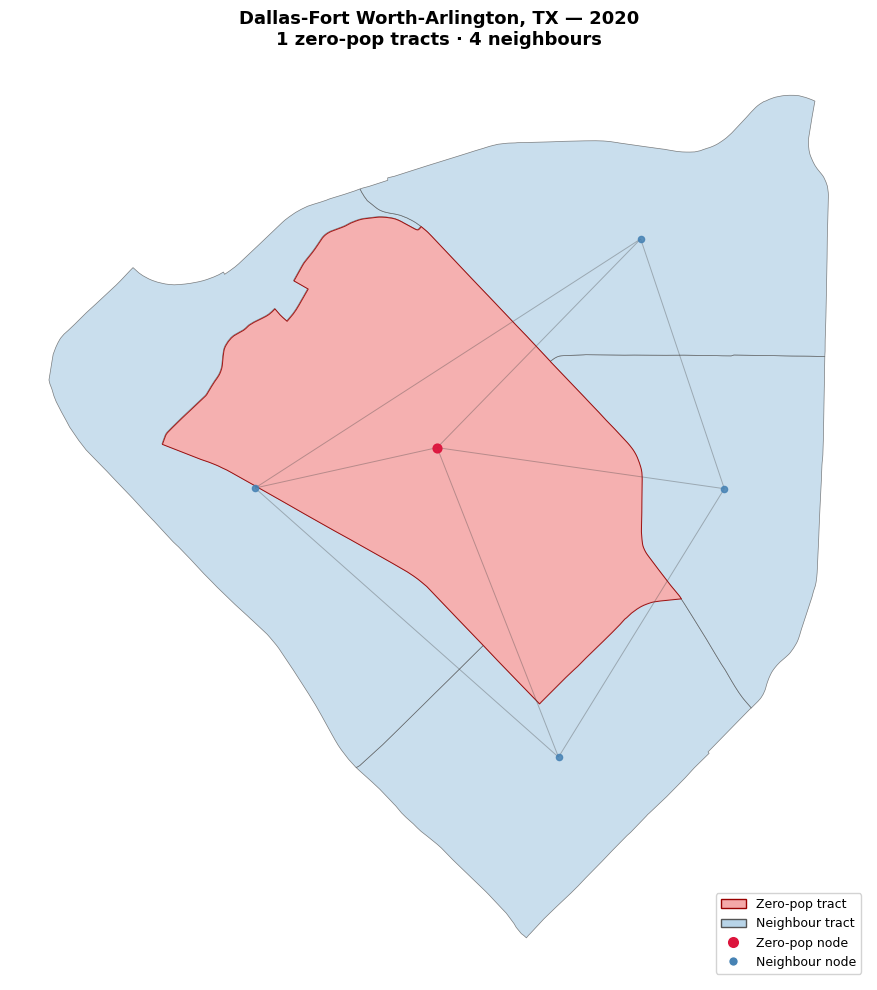


Dallas-Fort Worth-Arlington, TX — zero-pop node degrees
  Node  GISJOIN           Degree
----------------------------------
   730  G48113980100           4


In [97]:
plot_zero_pop_nodes(19100)

In [98]:
YEARS_ALL = [1980, 1990, 2000, 2010, 2020]


def find_orig_file_year(cbsa_code, year):
    pattern = os.path.join(
        CBSA_DIR, str(year),
        f'{CENSUS_GEOGRAPHY_TYPE}_in_cbsa_{cbsa_code}_{year}_*_vintage_orig.json'
    )
    matches = sorted(glob.glob(pattern))
    return matches[0] if matches else None


def plot_zero_pop_over_time(cbsa_code, out_dir=None):
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))

    fig, axes = plt.subplots(1, len(YEARS_ALL), figsize=(5 * len(YEARS_ALL), 6))
    fig.suptitle(f'{cbsa_name}\nZero-Pop Tracts & Neighbours Over Time',
                 fontsize=13, fontweight='bold')

    for ax, year in zip(axes, YEARS_ALL):
        ax.set_title(str(year), fontsize=11, pad=6)
        ax.set_axis_off()

        fp = find_orig_file_year(cbsa_code, year)
        if fp is None:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
            continue

        G = load_graph(fp)
        zero_nodes     = {n for n, d in G.nodes(data=True) if is_zero_pop(d)}
        neighbor_nodes = {nb for n in zero_nodes
                         for nb in G.neighbors(n) if nb not in zero_nodes}
        target_nodes   = zero_nodes | neighbor_nodes

        shp_path = fp.replace('_orig.json', '.shp')
        xlim, ylim = None, None

        if os.path.exists(shp_path):
            gdf = gpd.read_file(shp_path).to_crs('esri:102003')
            zero_gisjoin     = {G.nodes[n].get('GISJOIN') for n in zero_nodes}
            neighbor_gisjoin = {G.nodes[n].get('GISJOIN') for n in neighbor_nodes}

            gdf[gdf['GISJOIN'].isin(neighbor_gisjoin)].plot(
                ax=ax, color='#b8d4e8', edgecolor='#555', linewidth=0.5, alpha=0.75)
            gdf[gdf['GISJOIN'].isin(zero_gisjoin)].plot(
                ax=ax, color='#f4a8a8', edgecolor='#990000', linewidth=0.7, alpha=0.9)

            xlim, ylim = ax.get_xlim(), ax.get_ylim()

        # Graph overlay (only target nodes)
        if target_nodes:
            H   = G.subgraph(target_nodes)
            pos = {n: (G.nodes[n]['centroid_x'], G.nodes[n]['centroid_y'])
                   for n in target_nodes}
            nx.draw_networkx_edges(H, pos, ax=ax, alpha=0.35, width=0.7, edge_color='#444')
            if neighbor_nodes:
                nx.draw_networkx_nodes(H, pos, nodelist=list(neighbor_nodes), ax=ax,
                                       node_color='steelblue', node_size=12, alpha=0.85)
            if zero_nodes:
                nx.draw_networkx_nodes(H, pos, nodelist=list(zero_nodes), ax=ax,
                                       node_color='crimson', node_size=25, alpha=0.95)
            if xlim:
                ax.set_xlim(xlim)
                ax.set_ylim(ylim)

        ax.text(0.02, 0.02,
                f'{len(zero_nodes)} zero-pop\n{len(neighbor_nodes)} nbrs',
                transform=ax.transAxes, fontsize=8, va='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    legend_elements = [
        Patch(facecolor='#f4a8a8', edgecolor='#990000', label='Zero-pop tract'),
        Patch(facecolor='#b8d4e8', edgecolor='#555',    label='Neighbour tract'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=9,
               framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()

    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
        city = cbsa_name.split('-')[0].split(',')[0].strip().replace(' ', '_')
        fig.savefig(os.path.join(out_dir, f'{city}_zero_pop_over_time.png'),
                    dpi=150, bbox_inches='tight')

    plt.show()

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_90569/1618133194.py:44: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf['GISJOIN'].isin(neighbor_gisjoin)].plot(
/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_90569/1618133194.py:46: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf['GISJOIN'].isin(zero_gisjoin)].plot(


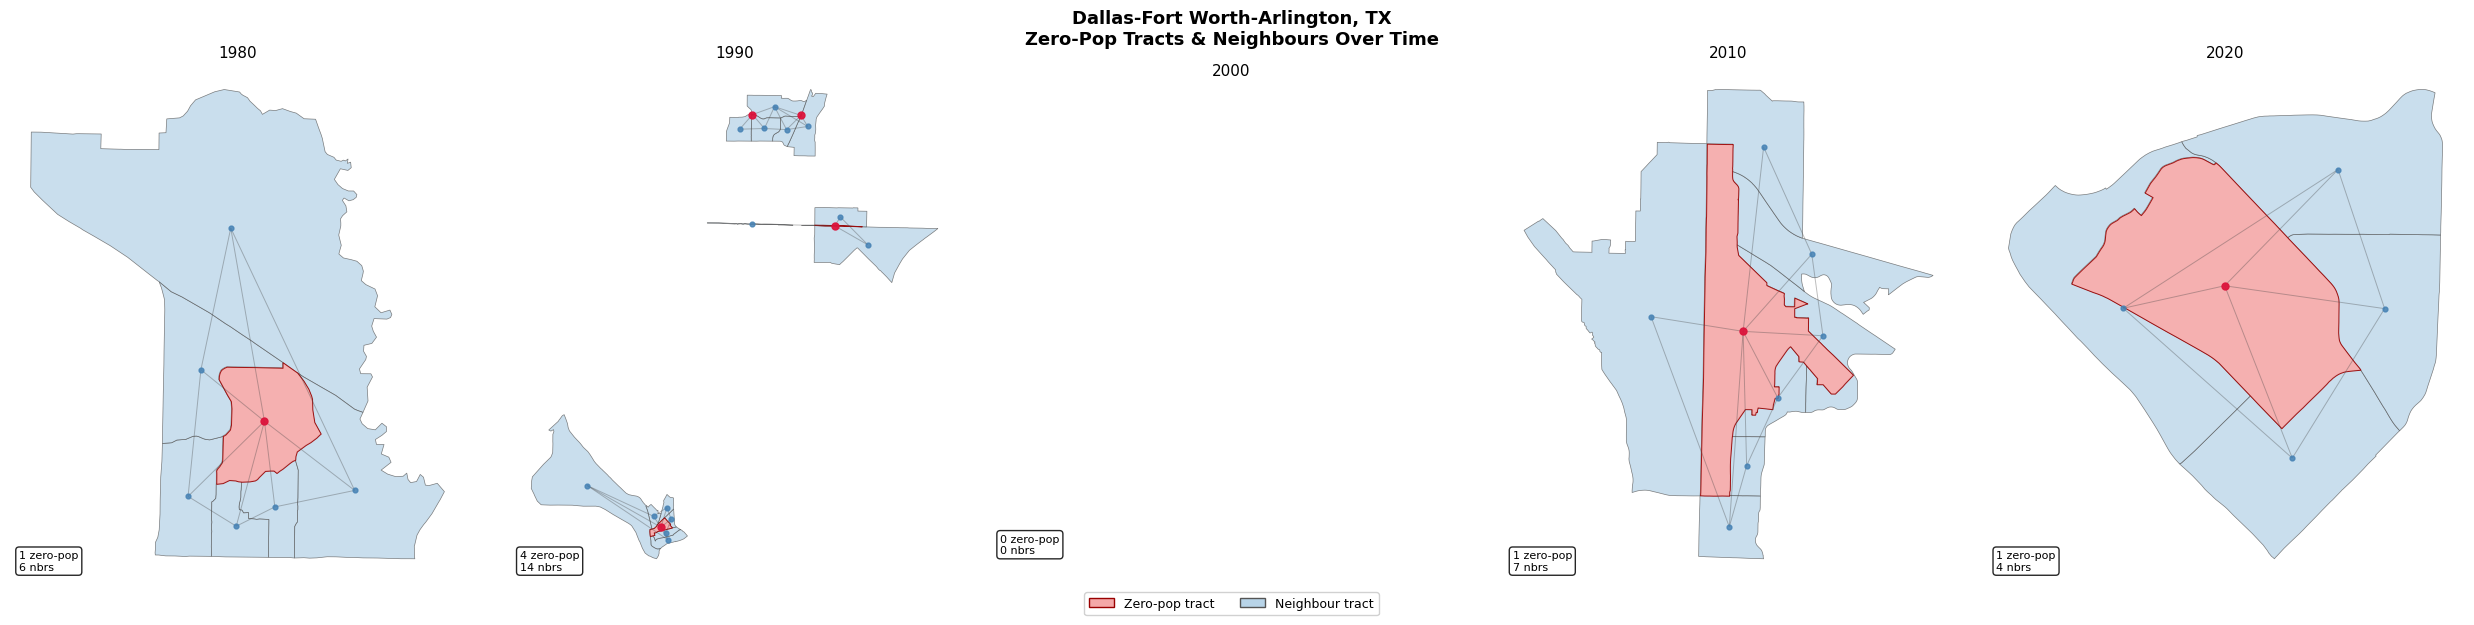

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_90569/1618133194.py:44: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf['GISJOIN'].isin(neighbor_gisjoin)].plot(
/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_90569/1618133194.py:46: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf['GISJOIN'].isin(zero_gisjoin)].plot(
/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_90569/1618133194.py:44: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf['GISJOIN'].isin(neighbor_gisjoin)].plot(
/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_90569/1618133194.py:46: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf[gdf['GISJOIN'].isin(zero_gisjoin)].plot(


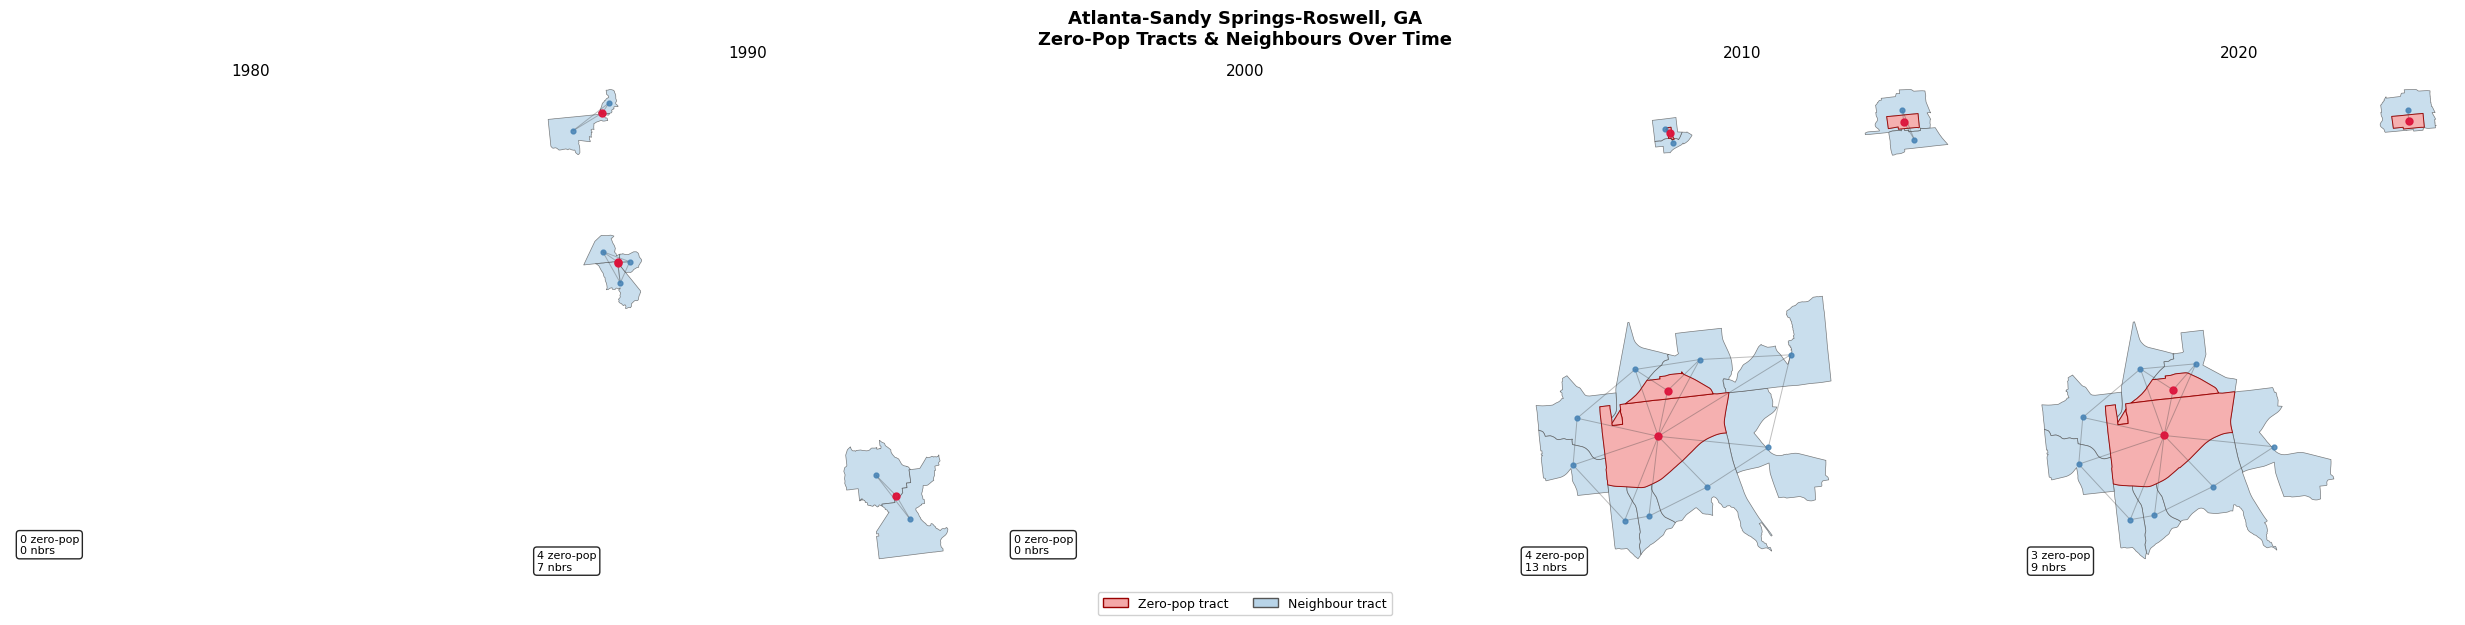

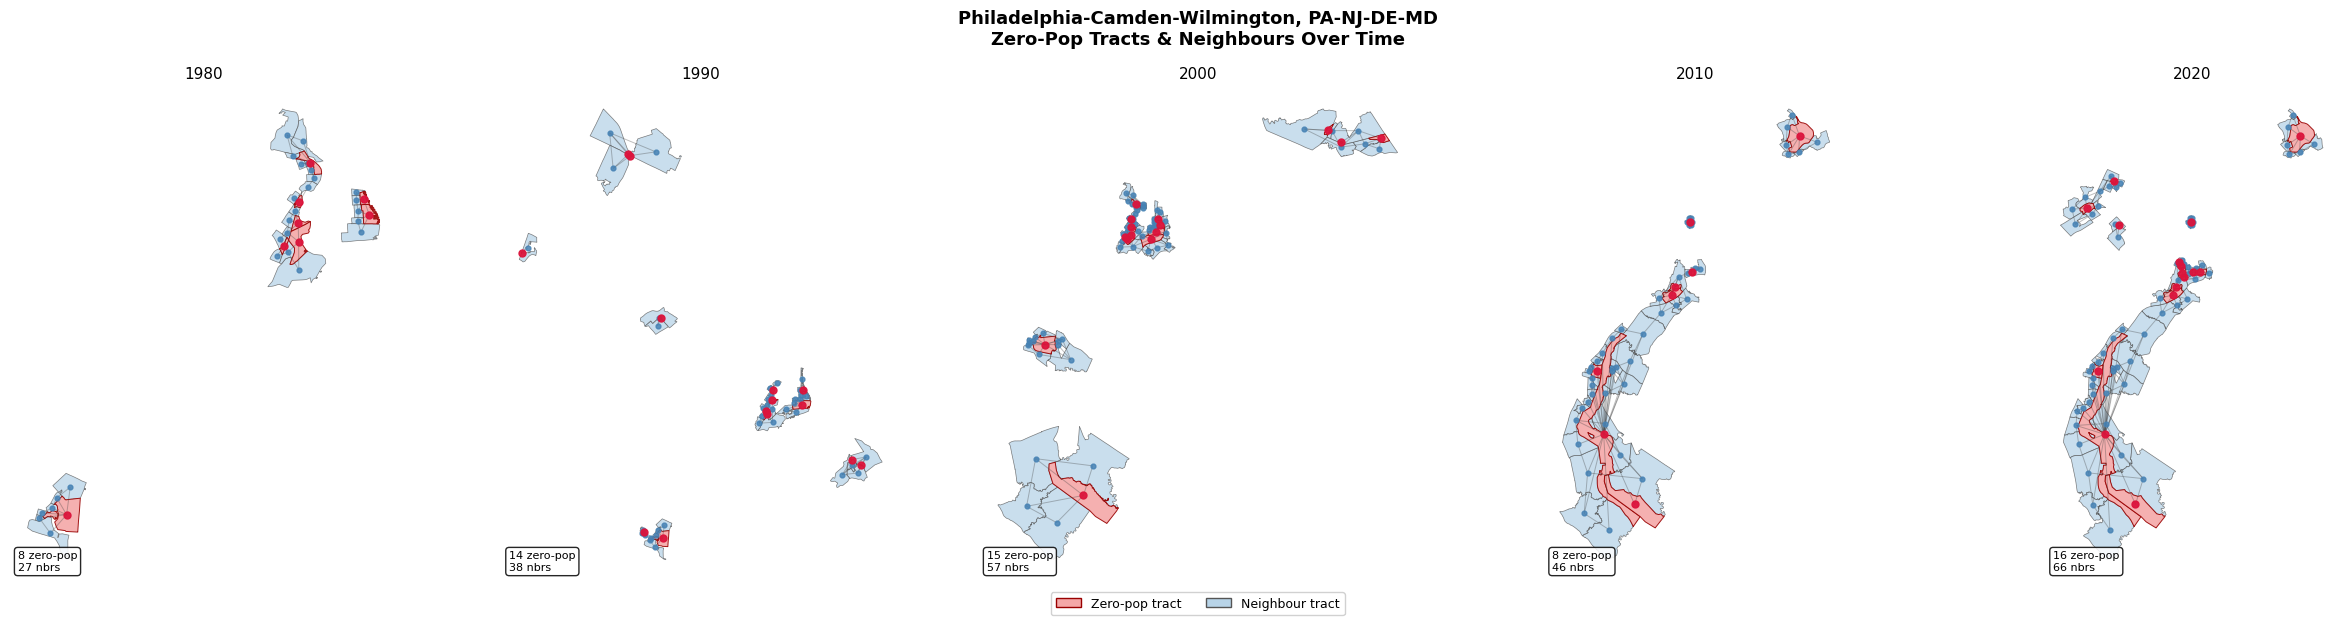

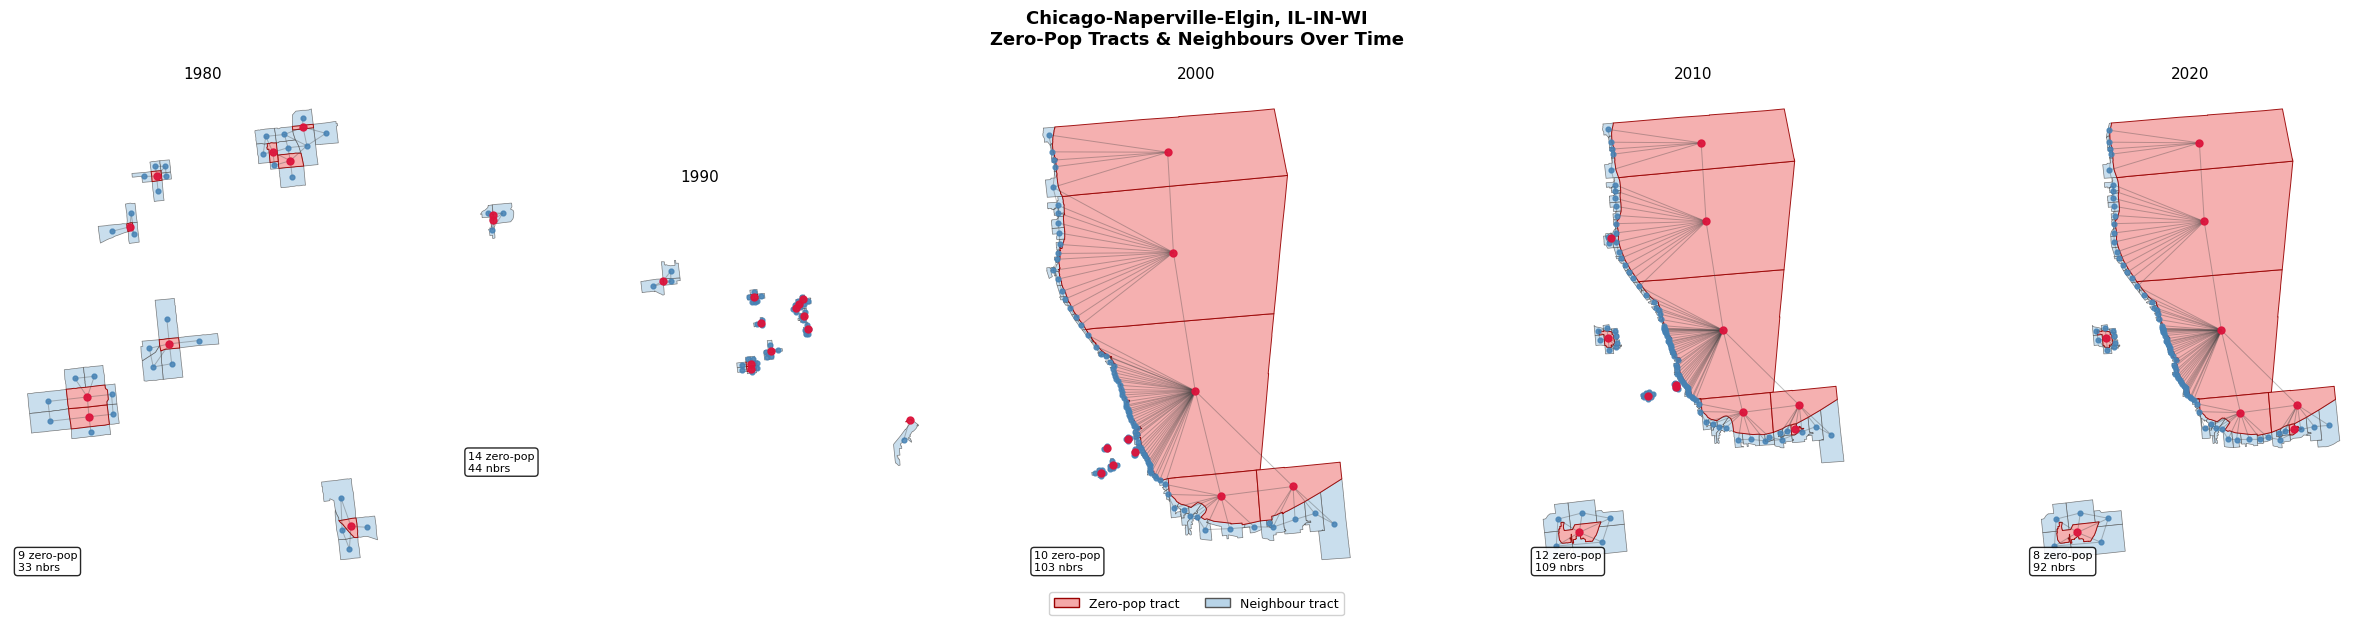

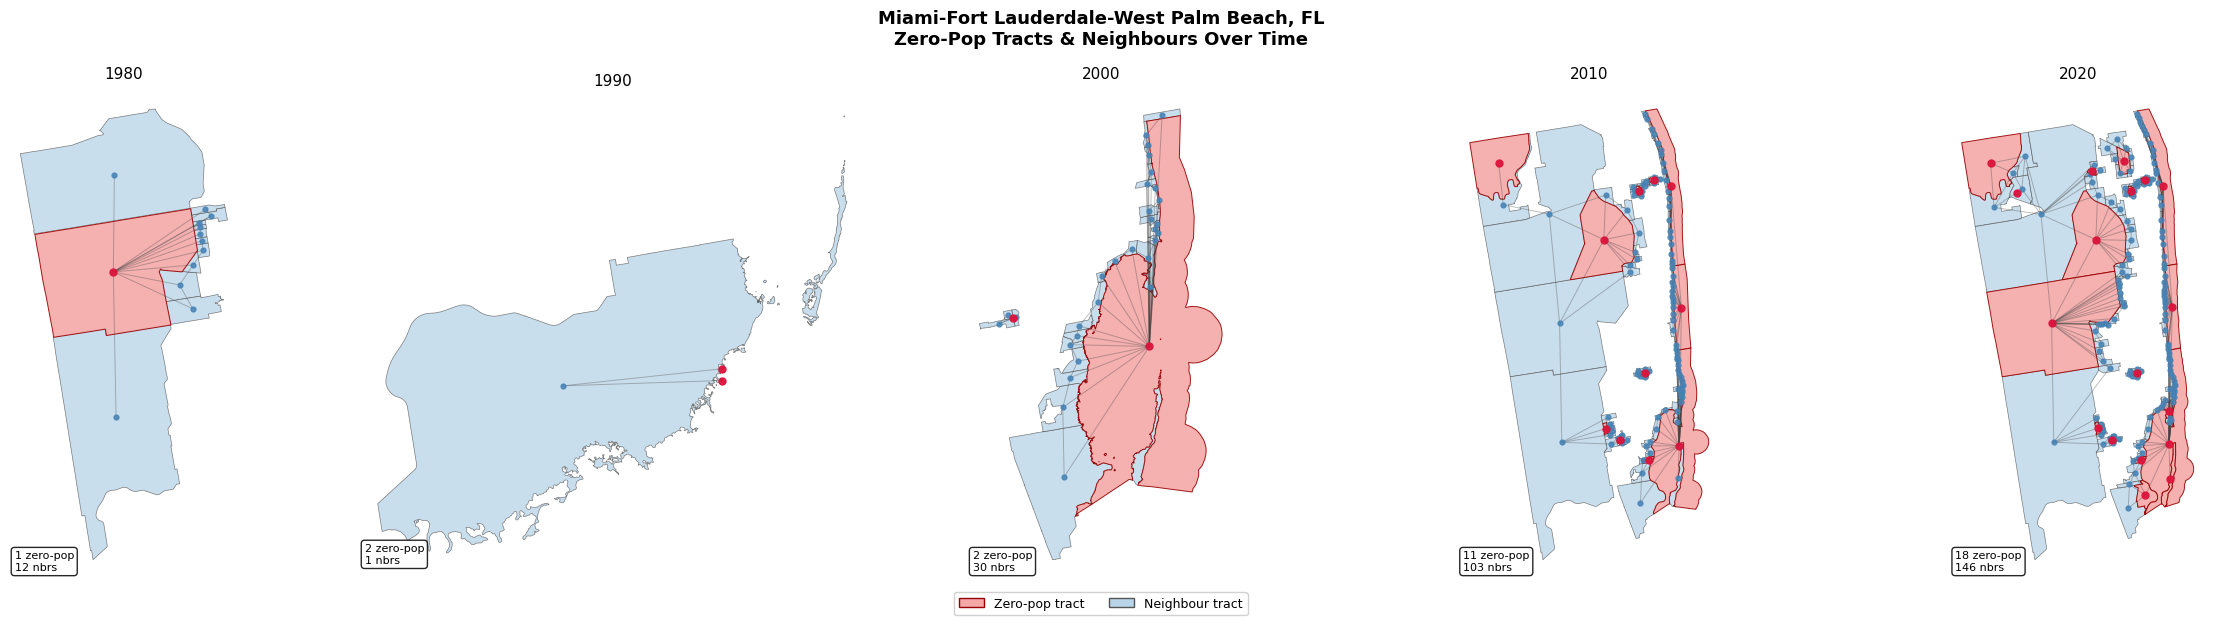

In [99]:
for cbsa_code in [19100, 12060, 37980, 16980, 33100]:  # Dallas, Atlanta, Philly, Chicago, Miami
    plot_zero_pop_over_time(cbsa_code)

In [100]:
def print_zero_pop_degrees_over_time(cbsa_code):
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))
    print(f'\n{"="*60}')
    print(f'{cbsa_name}  (CBSA {cbsa_code})')
    print(f'{"="*60}')

    for year in YEARS_ALL:
        fp = find_orig_file_year(cbsa_code, year)
        if fp is None:
            print(f'\n{year}: no orig file found')
            continue

        G = load_graph(fp)
        zero_nodes = [(n, G.degree(n)) for n, d in G.nodes(data=True) if is_zero_pop(d)]

        print(f'\n{year}  —  {len(zero_nodes)} zero-pop tract(s)')
        if zero_nodes:
            print(f'  {"GISJOIN":<18}  {"Degree":>6}')
            print(f'  {"-"*26}')
            for n, deg in sorted(zero_nodes, key=lambda x: -x[1]):
                gisjoin = G.nodes[n].get('GISJOIN', str(n))
                print(f'  {gisjoin:<18}  {deg:>6}')
        else:
            print('  (none)')

    print()


for cbsa_code in [19100, 12060, 37980, 16980, 33100]:
    print_zero_pop_degrees_over_time(cbsa_code)


Dallas-Fort Worth-Arlington, TX  (CBSA 19100)

1980  —  1 zero-pop tract(s)
  GISJOIN             Degree
  --------------------------
  G4801130014304           6

1990  —  4 zero-pop tract(s)
  GISJOIN             Degree
  --------------------------
  G48011300021             6
  G4800850031605           3
  G4800850031603           3
  G4801130020398           3

2000  —  0 zero-pop tract(s)
  (none)

2010  —  1 zero-pop tract(s)
  GISJOIN             Degree
  --------------------------
  G48113980000             7

2020  —  1 zero-pop tract(s)
  GISJOIN             Degree
  --------------------------
  G48113980100             4


Atlanta-Sandy Springs-Roswell, GA  (CBSA 12060)

1980  —  0 zero-pop tract(s)
  (none)

1990  —  4 zero-pop tract(s)
  GISJOIN             Degree
  --------------------------
  G1300970080797           3
  G1300670031698           2
  G1300350150498           2
  G1300670031697           2

2000  —  0 zero-pop tract(s)
  (none)

2010  —  4 zero-pop tract(